In [1]:
import sys
print(sys.executable)

d:\git\01_mdls_ds8_open\08_dl\260309_dl_practice\.venv\Scripts\python.exe


# 260309/dl/07_모델 저장과 콜백

## MNIST 딥러닝 모델 예제

### 데이터 로드 및 전처리

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, utils

In [3]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data(path='mnist.npz')

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full,
                                                  test_size=0.3,
                                                  random_state=123)

print(f"전체 학습 데이터: {x_train_full.shape}  레이블: {y_train_full.shape}")
print(f"학습용 데이터: {x_train.shape}  레이블: {y_train.shape}")
print(f"검증용 데이터: {x_val.shape}  레이블: {y_val.shape}")
print(f"테스트용 데이터: {x_test.shape}  레이블: {y_test.shape}")

전체 학습 데이터: (60000, 28, 28)  레이블: (60000,)
학습용 데이터: (42000, 28, 28)  레이블: (42000,)
검증용 데이터: (18000, 28, 28)  레이블: (18000,)
테스트용 데이터: (10000, 28, 28)  레이블: (10000,)


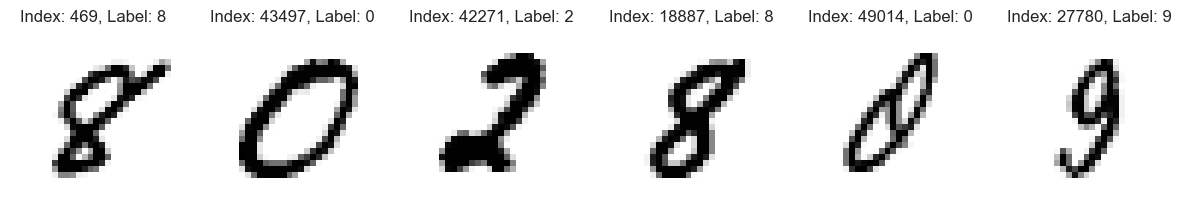

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

# MNIST 데이터셋에 실제 숫자 이미지가 어떻게 구성되어 있는지
# 60,000개 중에서 6개만 랜덤으로 x_train_full과 y_train_full에서 추출하여 
# 표시해보도록 하겠습니다.

num_sample = 6
random_idxs = np.random.randint(60000, size=num_sample)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(random_idxs):
  img = x_train_full[idx, :]
  label = y_train_full[idx]

  plt.subplot(1, len(random_idxs), i+1)
  plt.axis('off')
  plt.title(f'Index: {idx}, Label: {label}')
  plt.imshow(img)

4




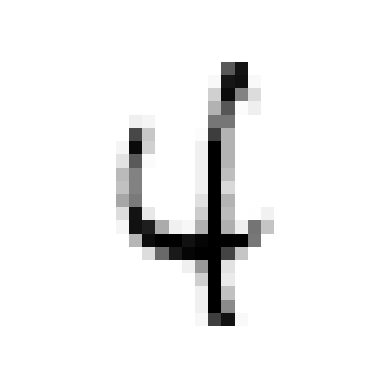

In [5]:
# MNIST의 학습용 데이터가 실제 값으로는 어떻게 구성되어있는지 출력을 해보면, 
# y_train의 0번째는 4라는 값이 저장되어 있는걸 알 수 있고, 
# x_train의 0번째에는 숫자 4에 대한 이미지를 0~255 사이의 값으로 표현하고 있음을 
# 알 수 있습니다.

print(y_train[0])
print('\n')

img = x_train[0, :]
plt.axis('off')
plt.imshow(img)

In [6]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 184 236
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  13 235 240
   11   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  73 244 144
   59   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 104 186   6
   32   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  33  21   0   0   0   0 15

In [7]:
# 본 예제에서는 간단한 전처리만 사용해서 
# x_train, x_val 그리고 x_test의 값들을 255로 나누어줍니다
# 미지의 픽셀이 표현하는 값의 범위가 0 ~ 255이기 때문에 
# 최대값인 255로 나누어주면, 값이 0 ~ 1 사이의 범위로 스케일링

x_train = x_train / 255.
x_val = x_val / 255.
x_test = x_test / 255.

# y_train, y_val, 그리고 y_test의 경우에는 0부터 9까지의 숫자를 나타내는 레이블이기 때문에 
# utils.to_categorical을 이용해 원-핫 인코딩을 수행

y_train = utils.to_categorical(y_train)
y_val = utils.to_categorical(y_val)
y_test = utils.to_categorical(y_test)

print(y_train[0])
print(y_val[0])
print(y_test[0])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


### 모델구성

d:\git\01_mdls_ds8_open\08_dl\260309_dl_practice\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,374 (341.30 KB)

 Trainable params: 87,374 (341.30 KB)

 Non-trainable params: 0 (0.00 B)

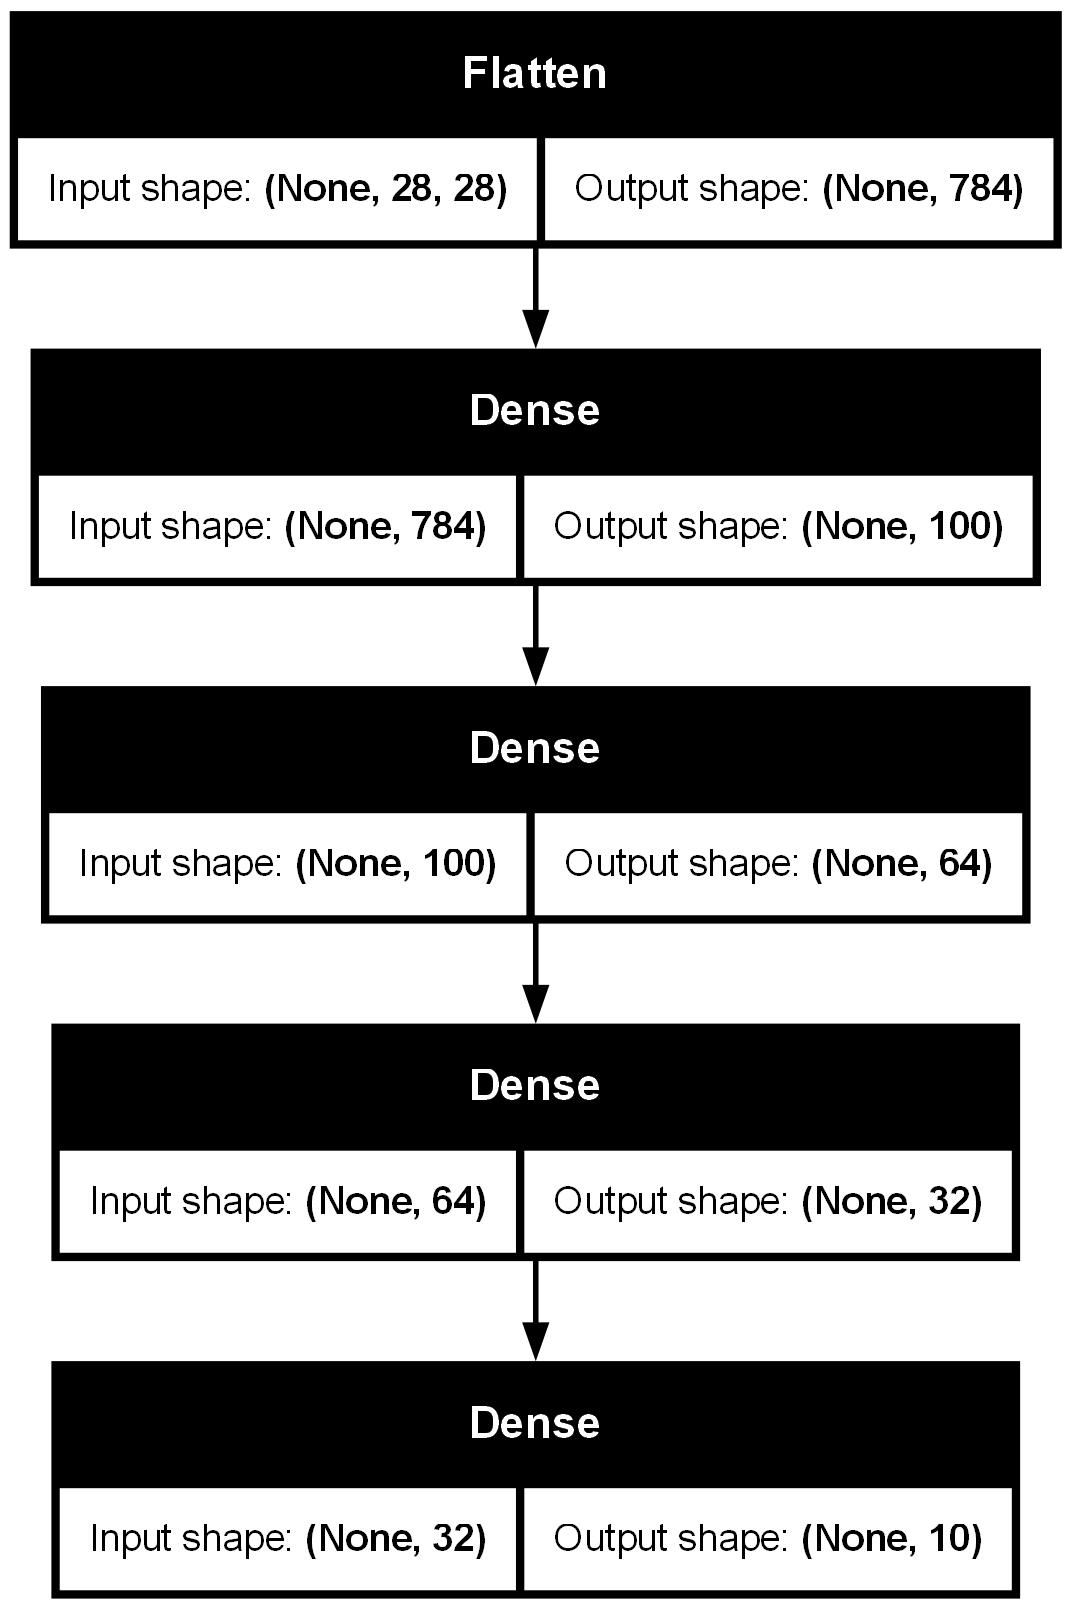

In [8]:
# Sequential() 함수를 이용해 순차적으로 레이어를 구성
# MNIST 데이터셋의 숫자 이미지가 28 x 28 사이즈를 사용하므로 
# 입력 객체로 keras.Input를 사용할 때, shape을 (28, 28)로 지정
# ayers.Flatten 레이어를 사용하여 입력 데이터 모양이 2차원인 28 x 28 크기를 
# 1차원으로 784 크기를 갖도록 변형

# 그 이후 레이어로 layers.Dense를 여러겹 사용하여 유닛수를 100, 64, 32, 10으로 4겹
# 활성화 함수로 relu를 사용
# 마지막 레이어에서는 전체 카테고리의 수인 10을 유닛수로 지정하고, 
# 활성화 함수는 softmax를 사용하여 각 카테고리별 확률 값 생성 

# ============================================================================
# [데이터 흐름 개요]
# 입력(28×28 이미지) → Flatten(784) → Dense(100) → Dense(64) → Dense(32) → 출력(10개 클래스)
# [출력은 왜 softmax?]
# - 이진 분류: sigmoid (출력 1개)
# - 다중 분류: softmax (출력 N개, 상호 배타적)
# ============================================================================

model = models.Sequential()
model.add(keras.Input(shape=(28, 28), name='input'))
model.add(layers.Flatten(input_shape=[28, 28], name='flatten'))
model.add(layers.Dense(100, activation='relu', name='dense1'))
model.add(layers.Dense(64, activation='relu', name='dense2'))
model.add(layers.Dense(32, activation='relu', name='dense3'))
model.add(layers.Dense(10, activation='softmax', name='output'))
model.summary()

# 생성한 모델의 구성을 그림을 통해 확인합니다.
utils.plot_model(model)

# 모델의 구성을 각 레이어의 모양까지 함께 살펴보도록 합니다.
utils.plot_model(model, show_shapes=True)

### 모델 컴파일 및 학습
- Keras에서 compile = "학습 전략 설정", 모델을 어떻게 학습시킬지 규칙을 정의하는 단계
    1. model = Sequential([...])   ← 모델 구조 정의 (뇌의 뉴런 배치)
    2. model.compile(...)          ← 학습 전략 설정 (어떻게 공부할지)
    3. model.fit(...)              ← 실제 학습 시작 (공부 시작)
    4. model.evaluate(...)         ← 테스트 (시험)

| 인자 | 비유 | 역할 |
|------|------|------|
| `loss` | 시험 채점 기준 | 예측과 정답의 차이를 숫자로 계산하는 함수 |
| `optimizer` | 공부 전략 | loss를 줄이기 위해 가중치를 어떻게 업데이트할지 |
| `metrics` | 성적표 항목 | 학습 중 모니터링할 지표 (학습에 직접 영향 X) |

In [9]:
# 손실 함수로는 다중 분류로 클래스가 원-핫 인코딩 방식으로 되어 있을 때 사용하는 categorical_crossentropy를 지정
# 옵티마이저는 가장 기본적인 sgd을 지정
# 분류에 대한 성능을 확인하기 위한 지표로 accuracy를 지정
model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

# compile()은 설정만 저장하고, 실제 계산은 fit()에서 시작

In [10]:
history = model.fit(x_train, y_train,
                   epochs=50,
                   batch_size=128,
                   validation_data=(x_val, y_val))
                   
                   
# 모델이 학습을 진행하면서 각 에폭마다 지표 결과들을 history로 저장을 합니다. 
# 저장된 형태를 보면 loss, accuracy, val_loss, val_accuracy로 구분되는걸 알 수 있습니다.
history.history.keys()

# history 객체fit()은 학습 과정의 기록을 History 객체로 반환.pythonhistory.history.keys()
# dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4131 - loss: 1.8766 - val_accuracy: 0.7191 - val_loss: 1.2113
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8114 - loss: 0.7880 - val_accuracy: 0.8491 - val_loss: 0.5654
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8714 - loss: 0.4778 - val_accuracy: 0.8680 - val_loss: 0.4542
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8915 - loss: 0.3909 - val_accuracy: 0.8913 - val_loss: 0.3705
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9015 - loss: 0.3481 - val_accuracy: 0.9010 - val_loss: 0.3397
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9090 - loss: 0.3195 - val_accuracy: 0.9054 - val_loss: 0.3153
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9146 - loss: 0.2989 - val_accuracy: 0.9081 - val_loss: 0.3022
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9194 - loss: 0.2816 - val_accuracy: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

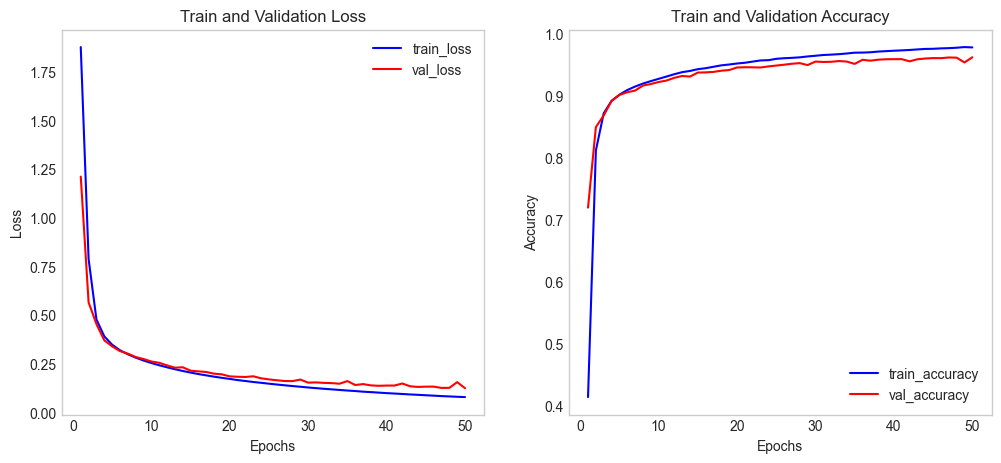

In [11]:
# history 저장된 결과 값 시각화
# 첫 번째 차트: `loss`와 `val_loss`를 함께
# 두 번째 차트:  `accuracy`와 `val_accuracy`를 함께

history_dict = history.history # history.history는 딕셔너리(사전) 형태

# 데이터 추출
loss = history_dict['loss'] # 훈련 손실값 리스트 (epoch별로 저장됨)
val_loss = history_dict['val_loss'] # 검증 손실값 리스트 (학습에 안 쓴 데이터로 측정한 손실)
accuracy = history_dict['accuracy'] # 훈련 정확도 리스트
val_accuracy = history_dict['val_accuracy'] # 검증 정확도 리스트

# 그래프 틀 만들기
epochs = range(1, len(loss) + 1)  # x축(에폭 번호) 만들기
fig = plt.figure(figsize=(12, 5)) # 그림(Figure) 틀 만들기

# 첫 번째 차트 (Loss 그래프)
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='red', label='val_loss')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

# 두 번째 차트 (Accuracy 그래프)
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, color='blue', label='train_accuracy')
ax2.plot(epochs, val_accuracy, color='red', label='val_accuracy')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

### 모델 평가 및 예측

In [12]:
# 학습된 모델의 평가를 위해서 x_test와 y_test를 대상으로 evaluate() 함수 계산 
model.evaluate(x_test, y_test)

# 학습된 모델의 예측을 위해 x_test를 넣고, 그에 대한 예측 결과를 받아서 0번째 결과만 확인을 해보면, 
# 최종 레이어인 유닛 수 10개의 softmax를 활성화 함수로 통과한 결과인 것을 알 수 있습니다.
print('\n')
pred_ys = model.predict(x_test) # 테스트 이미지들을 모델에 넣고 "이게 뭔지 맞혀봐"
print(pred_ys.shape) # Shape 확인 (10000, 10)
print(pred_ys[0]) # 첫 번째 이미지 예측 결과 -> 모델이 이미지를 "7"이라고 99.85% 확신

# 클래스:  0    1    2    3    4    5    6    7    8    9
# 확률:   ·    ·    ·    ·    ·    ·    ·    █    ·    ·
#                                           ↑
#                                        99.85%

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9652 - loss: 0.1124


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
(10000, 10)
[2.3311610e-05 2.5132189e-07 5.3278978e-05 4.4083770e-04 8.9952458e-08
 4.3905875e-05 1.5428124e-10 9.9937940e-01 1.0563373e-06 5.7868601e-05]


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.96      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.96      0.96       892
           6       0.96      0.97      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.95      0.95      0.95       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.97      0.97      0.97     10000



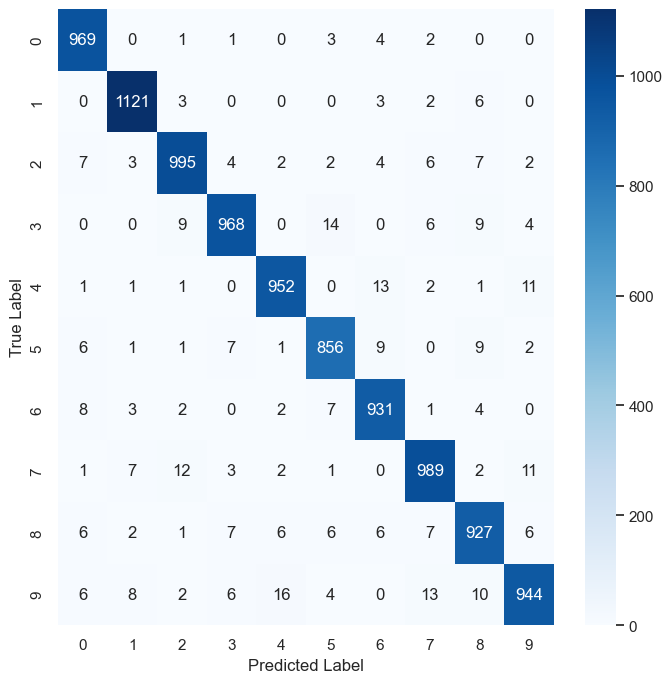

In [13]:
# 결과값 중에서 가장 큰 수가 있는 위치값을 np.argmax()를 통해서 구하고, 
# 예측한 레이블 값 arg_pred_y[0]과 실제 숫자 이미지인 x_test[0]를 출력해봅니다.
# 그 후 혼동 행렬(Confusion Matrix)을 이용해 시각화합니다.

from sklearn.metrics import classification_report

# np.argmax() - 가장 큰 값의 위치 찾기
print(classification_report
      (np.argmax(y_test, axis=-1),   # 정답을 숫자로
       np.argmax(pred_ys, axis=-1))) # 예측을 숫자로

from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.set(style='white')
plt.figure(figsize=(8, 8))

# cm = confusion_matrix(정답들, 예측들)
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(pred_ys, axis=-1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')        # x축: 예측값
plt.ylabel('True Label')             # y축: 실제 정답
plt.show()

## ★ 모델 저장과 로드

In [14]:
# 모델을 저장할 때는 `save()` 함수를 사용하여 쉽게 저장할 수 있고
# 다시 모델을 불러올 때는 `load_model()` 함수를 사용하면 됩니다.

#  Sequencial API ,Functional API 는 모델의 저장 및 로드가 가능하지만 Subclassing API 는 불가능 
# Subclassing API 방식은 `save_weights()`와 `load_weights()`를 이용해 모델의 파라미터만 저장 및 로드


# mnist_model.h5라는 이름으로 모델을 저장합니다.
model.save('mnist_model.h5')

# mnist_model.h5라는 이름의 모델을 로드하여 가져옵니다.
loaded_model = models.load_model('mnist_model.h5')
loaded_model.summary()

# 로드한 모델을 이용하여 예측하는 것이 가능합니다.
pred_ys2 = loaded_model.predict(x_test)
print(pred_ys2.shape)
print(pred_ys2[0])



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,376 (341.32 KB)

 Trainable params: 87,374 (341.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step
(10000, 10)
[2.3311610e-05 2.5132189e-07 5.3278978e-05 4.4083770e-04 8.9952458e-08
 4.3905875e-05 1.5428124e-10 9.9937940e-01 1.0563373e-06 5.7868601e-05]


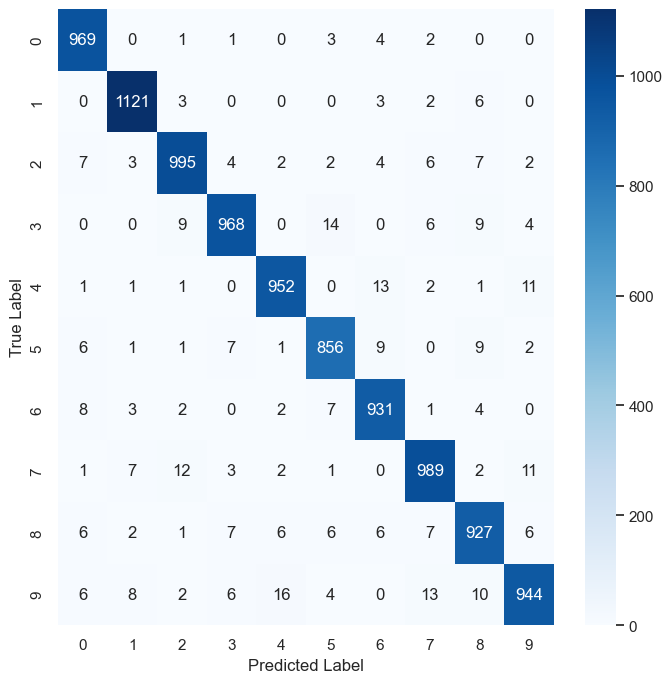

In [15]:
#예측값 시각화하기
arg_pred_y2 = np.argmax(pred_ys2, axis=1)

#matlotlib를 이용해서 시각화하기
sns.set(style='white')

cm = confusion_matrix(
    np.argmax(y_test, axis=1),
    np.argmax(pred_ys, axis=-1)
)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [16]:
# Q. to_json() 함수를 이용해 모델을 저장해보고 다시 불러서 결과를 확인해보세요. 결과가 같은가요, 다른가요?

# 위에서 학습시킨 model의 구조를 json 형식으로 model_json에 저장합니다.
model_json = model.to_json()

# json으로 저장한 모델을 읽어옵니다.
# to_json()으로 불러온 모델 = 학습 안 된 새 모델
# 가중치가 랜덤 초기화 상태

loaded_model = keras.models.model_from_json(model_json)

predictions = loaded_model.predict(x_test)
print(predictions.shape)
print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 10)
[0.08536017 0.094358   0.11468538 0.09009277 0.08793877 0.08762418
 0.10919974 0.09757403 0.13027312 0.10289384]


In [17]:
# 저장
model_json = model.to_json()                    # 구조 저장
model.save_weights('mnist_weights.weights.h5')  # 가중치 저장

# 로드
loaded_model = keras.models.model_from_json(model_json)  # 구조 로드
loaded_model.load_weights('mnist_weights.weights.h5')    # 가중치 로드

# 이제 동일한 결과!
predictions = loaded_model.predict(x_test)
print(predictions[0])  # [0.00, ..., 0.998, ...] ← 99.8% 확신

 68/313 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step

d:\git\01_mdls_ds8_open\08_dl\260309_dl_practice\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step
[2.3311610e-05 2.5132189e-07 5.3278978e-05 4.4083770e-04 8.9952458e-08
 4.3905875e-05 1.5428124e-10 9.9937940e-01 1.0563373e-06 5.7868601e-05]


## 콜백

### ModelCheckpoint

- 모델을 `fit()` 함수를 통해 학습시키는 동안
- `callbacks` 매개변수를 사용하여 학습 시작이나 끝에 호출할 객체 리스트를 여러 개 지정할 수 있습니다.
- 콜백의 대표적인 예로는 ModelCheckpoint, EarlyStopping, LearningRateScheduler, Tensorboard가 있습니다.

In [18]:
from tensorflow.keras import callbacks #  tensorflow.keras.callbacks 임포트

# tf.keras.callbacks.ModelCheckpoint 
# 정기적으로 모델의 체크포인트를 저장하고, 문제가 발생할 때 복구하는데 사용

check_point_cb = callbacks.ModelCheckpoint('keras_mnist_model.h5')
history = model.fit(x_train, y_train, epochs=10,
                    callbacks=[check_point_cb])
                    
# 최상의 모델만을 저장하는 옵션으로 save_best_only=True를 지정합니다.
check_point_cb = callbacks.ModelCheckpoint('keras_mnist_model.h5', save_best_only=True)
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_val, y_val),
                    callbacks=[check_point_cb])

Epoch 1/10
1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9752 - loss: 0.0870

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0861
Epoch 2/10
1295/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9772 - loss: 0.0791

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9769 - loss: 0.0801
Epoch 3/10
1290/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9785 - loss: 0.0750

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9788 - loss: 0.0737
Epoch 4/10
1296/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9796 - loss: 0.0699

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9801 - loss: 0.0683
Epoch 5/10
1299/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9818 - loss: 0.0648

...

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9870 - loss: 0.0468
Epoch 10/10
1305/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9886 - loss: 0.0414

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9875 - loss: 0.0440
Epoch 1/10
1309/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9890 - loss: 0.0401

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9890 - loss: 0.0413 - val_accuracy: 0.9683 - val_loss: 0.1121
Epoch 2/10
1275/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9891 - loss: 0.0387

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9898 - loss: 0.0381 - val_accuracy: 0.9683 - val_loss: 0.1087
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9906 - loss: 0.0351 - val_accuracy: 0.9684 - val_loss: 0.1137
Epoch 4/10
1273/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9914 - loss: 0.0324

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9910 - loss: 0.0329 - val_accuracy: 0.9706 - val_loss: 0.1072
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9920 - loss: 0.0300 - val_accuracy: 0.9644 - val_loss: 0.1303
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9933 - loss: 0.0277 - val_accuracy: 0.9676 - val_loss: 0.1145
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9930 - loss: 0.0259 - val_accuracy: 0.9677 - val_loss: 0.1197
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9939 - loss: 0.0245 - val_accuracy: 0.9683 - val_loss: 0.1145
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9943 - loss: 0.0230 - val_accuracy: 0.9704 - val_loss: 0.1112
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9953 - loss: 0.0205 - val_accuracy: 0.9694 - val_loss: 0.1168


In [19]:
print(type(check_point_cb))
# <class 'keras.callbacks.ModelCheckpoint'>

print(check_point_cb.filepath)
# 'keras_mnist_model.h5'

<class 'keras.src.callbacks.model_checkpoint.ModelCheckpoint'>
keras_mnist_model.h5


### EarlyStopping

In [20]:
# tf.keras.callbacks.EarlyStopping: 검증 성능이 한동안 개선되지 않을 경우 학습을 중단할 때 사용
check_point_cb = callbacks.ModelCheckpoint('keras_mnist_model.h5', save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=3, monitor='val_loss',
                                  restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_val, y_val),
                    callbacks=[check_point_cb, early_stopping_cb])

Epoch 1/10
1306/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9959 - loss: 0.0179

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9955 - loss: 0.0190 - val_accuracy: 0.9693 - val_loss: 0.1147
Epoch 2/10
1305/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9956 - loss: 0.0186

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9960 - loss: 0.0181 - val_accuracy: 0.9711 - val_loss: 0.1096
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9968 - loss: 0.0158 - val_accuracy: 0.9712 - val_loss: 0.1121
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9970 - loss: 0.0148 - val_accuracy: 0.9699 - val_loss: 0.1158
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9976 - loss: 0.0133 - val_accuracy: 0.9684 - val_loss: 0.1230


### LearningRateScheduler

In [21]:
import math # Keras 3.x의 LearningRateScheduler는 순수 Python float만 허용

def scheduler(epoch, learning_rate):
  if epoch < 10:
    return learning_rate
  else:
    # return learning_rate * tf.math.exp(-0.1) 구버전
    return learning_rate * math.exp(-0.1)  # 신버전 float 반환
  
# round(model.optimizer.lr.numpy(), 5) 구버전 
round(model.optimizer.learning_rate.numpy(), 5)  # 신버전


lr_scheduler_cb = callbacks.LearningRateScheduler(scheduler)

history = model.fit(x_train, y_train, epochs=15,
                    callbacks=[lr_scheduler_cb], verbose=0)

# round(model.optimizer.lr.numpy(), 5) 구버전
round(model.optimizer.learning_rate.numpy(), 5)  # 신버전

0.00607

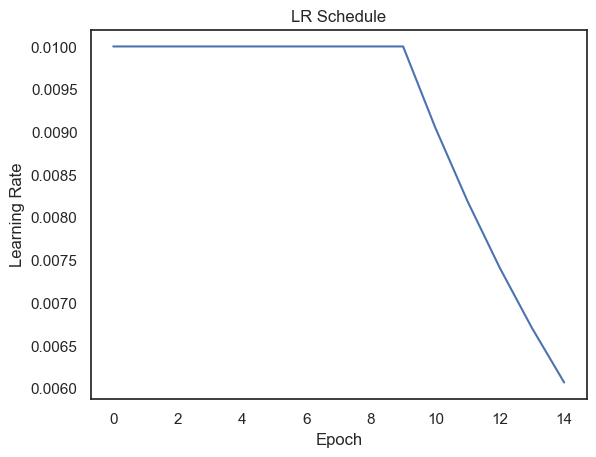

In [22]:
# lr 변화 추이 시각화
lrs = [0.01]
for epoch in range(1, 15):
    lrs.append(scheduler(epoch, lrs[-1]))

plt.plot(lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('LR Schedule')
plt.show()

### Tensorboard

In [23]:
# tf.keras.callbacks.TensorBoard: 모델의 경과를 모니터링할 때 사용
log_dir = './logs'  # 로그 저장 경로
tensor_board_cb = [callbacks.TensorBoard(log_dir=log_dir, 
                                         histogram_freq=1,   # 가중치 히스토그램 기록 빈도(1 = 매 epoch마다 기록)
                                         write_graph=True,   # 모델 구조(그래프)를 저장할지 True → Graphs 탭에서 모델 구조 시각화 가능
                                         write_images=True)] # 가중치를 이미지로 저장할지 True → 가중치 행렬을 흑백 이미지처럼 시각화
model.fit(x_train, y_train, 
          batch_size=32, 
          validation_data=(x_val, y_val),
          epochs=30, 
          callbacks=tensor_board_cb)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9998 - loss: 0.0047 - val_accuracy: 0.9718 - val_loss: 0.1215
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0045 - val_accuracy: 0.9716 - val_loss: 0.1233
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 0.0044 - val_accuracy: 0.9712 - val_loss: 0.1234
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9999 - loss: 0.0042 - val_accuracy: 0.9712 - val_loss: 0.1244
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0041 - val_accuracy: 0.9711 - val_loss: 0.1248
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0039 - val_accuracy: 0.9714 - val_loss: 0.1245
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0037 - val_accuracy: 0.9712 - val_loss: 0.1257
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 0.0036 - 

In [24]:
# tensorboard 설치 확인
# pip install tensorboard

# 주피터 환경 실행 
%load_ext tensorboard
%tensorboard --logdir ./logs

Reusing TensorBoard on port 6006 (pid 24544), started 1:35:47 ago. (Use '!kill 24544' to kill it.)

## 종합퀴즈 

In [25]:
# 기존에 사용했던 mnist의 데이터들을 활용해서 모델에 checkpoint를 만들고 Earlystopping을 설정해주세요.
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping  

check_point_cb = ModelCheckpoint(
    filepath='mnist_checkpoint.h5',  # 저장할 파일 이름 (.h5는 Keras 모델 형식)
    monitor='val_loss',              # 뭘 기준으로 "좋다/나쁘다" 판단할지 → 검증 손실
    save_best_only=True)             # True: 최고 성능일 때만 저장 (용량 절약)
                                     # False: 매 epoch마다 저장 (덮어쓰기)

# [[YOUR CODE]]
early_stopping_cb = EarlyStopping(
    monitor='val_loss',           # 감시할 지표 (검증 손실)
    patience=3,                   # 몇 번 연속 개선 없으면 멈출지 (3 epoch 참음)
    restore_best_weights=True)    # True: 멈출 때 가장 좋았던 가중치로 복원
                                  # False: 마지막 epoch 가중치 그대로 (보통 더 나쁨)

history = model.fit(x_train, y_train, 
                    epochs=10,                    
                    validation_data=(x_val, y_val),  # 검증 데이터 (monitor 지표 계산용)
                    callbacks=[check_point_cb, early_stopping_cb])  # 콜백 리스트로 전달

Epoch 1/10
1286/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0019

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9713 - val_loss: 0.1368
Epoch 2/10
1294/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0019

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9714 - val_loss: 0.1357
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9712 - val_loss: 0.1370
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9714 - val_loss: 0.1366
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9709 - val_loss: 0.1364


# [참고]저장, 로드, 텐서보드 사용을 위해 주피터 노트 상단에 들어가야하는 코드

In [26]:
# # ============================================================
# # 0. 기본 임포트
# # ============================================================
# from tensorflow.keras import callbacks
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# import datetime
# import shutil
# 
# # ============================================================
# # 1. TensorBoard 설정 (학습 과정 시각화)
# # ============================================================
# # 실험마다 새 폴더 생성 (로그 섞임 방지)
# log_dir = f"./logs/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
# 
# tensor_board_cb = callbacks.TensorBoard(
#     log_dir=log_dir,
#     histogram_freq=1,
#     write_graph=True,
#     write_images=True)
# 
# # ============================================================
# # 2. ModelCheckpoint 설정 (최고 성능 모델 저장)
# # ============================================================
# check_point_cb = ModelCheckpoint(
#     filepath='best_model.h5',
#     monitor='val_loss',
#     save_best_only=True)
# 
# # ============================================================
# # 3. 콜백 리스트 (fit()에 전달용)
# # ============================================================
# all_callbacks = [tensor_board_cb, check_point_cb, early_stopping_cb]
"""
# 콜백(callbacks) -> 학습 중 자동으로 "뭔가" 해주는 것
    - 저장, 기록, EarlyStopping
    - 설정 수정 
    * 콜백 = Keras가 대신 돌려주는 반복문 + 함수 묶음
------------------------------------------------------------
# 콜백 종류별 역할
    - ModelCheckpoint : 모델 저장
    - TensorBoard : 로그 기록
    - EarlyStopping : 학습 멈춤
    - LearningRateScheduler : 학습률 변경
    - ReduceLROnPlateau : 성능 정체되면 lr 낮춤
    - CSVLogger결과를 : CSV 파일로 저장
    - ProgbarLogger : 진행바 표시 (기본 내장)
    - TerminateOnNaN : loss가 NaN 되면 즉시 멈춤
    - LambdaCallback : 내가 원하는 함수 실행
"""

# # ============================================================
# # [선택사항] EarlyStopping 설정 (과적합 방지)
# # ============================================================
# early_stopping_cb = EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True)

'\n# 콜백(callbacks) -> 학습 중 자동으로 "뭔가" 해주는 것\n    - 저장, 기록, EarlyStopping\n    - 설정 수정 \n    * 콜백 = Keras가 대신 돌려주는 반복문 + 함수 묶음\n------------------------------------------------------------\n# 콜백 종류별 역할\n    - ModelCheckpoint : 모델 저장\n    - TensorBoard : 로그 기록\n    - EarlyStopping : 학습 멈춤\n    - LearningRateScheduler : 학습률 변경\n    - ReduceLROnPlateau : 성능 정체되면 lr 낮춤\n    - CSVLogger결과를 : CSV 파일로 저장\n    - ProgbarLogger : 진행바 표시 (기본 내장)\n    - TerminateOnNaN : loss가 NaN 되면 즉시 멈춤\n    - LambdaCallback : 내가 원하는 함수 실행\n'

# 260309/dl/08_모델 학습 기술

## IMDB 딥러닝 모델 예제

### 데이터 로드 및 전처리

In [27]:
from keras.datasets import imdb
import numpy as np

# 영화 사이트 IMDB의 리뷰 데이터를 모아놓은 것으로 텍스트 분류, 감성 분류를 위해 자주 사용하는 데이터
# 리뷰 텍스트와 레이블로 구성되어 있고, 레이블은 리뷰가 긍정인 경우 1을 부정인 경우 0

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print(train_data[0])
print(train_labels[0])

# IMDB의 데이터셋은 인덱스로만 구성되어 있기 때문에 실제 단어들로 변환하기 위해서는 
# 단어 인덱스 딕셔너리를 이용해야하며, imdb.get_word_index()  함수를 통해 얻을 수 있음 

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


In [28]:
word_index = imdb.get_word_index()
word_index # 원본 딕셔너리

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [29]:
index_word = dict([(value, key) for (key, value) in word_index.items()])
index_word # key-value를 뒤집은 딕셔너리

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [30]:
# imdb.get_word_index() 함수를 통해 얻은 데이터의 index는 
# 단어 출현 빈도 기준으로 내림차수 정렬되어있습니다. 
# 따라서 아래 코드블럭의 index_word 의 키 값을 바꿔가며 
# 해당 출현 빈도 순에 해당하는 단어를 살펴볼 수 있어요.


# 1 순위의 출현 빈도를 기록한 단어를 출력합니다.
# 일반 Python 리스트는 0부터지만, NLP 전처리 편의를 위해 1부터 시작하도록 설계됨 
# 0이 실제 단어였다면 패딩과 구분이 안 되니까, 0은 비워두고 단어는 1부터 시작
index_word[1]


'the'

In [31]:
# Q. 25번째 단어를 키로 삼아 word_index에 어떤 값(value)가 담겨있는지 확인해 봅시다.
word_25th = index_word[25]
print(word_25th)

have


In [32]:
# train_data[0]의 각 인덱스에 매핑되는 단어들로 연결하여 하나의 리뷰를 만들어 줍니다.

review = ' '.join([str(i) for i in train_data[0]])
print(review)

# 왜 i-3? -> 데이터에 특수 토큰 3개가 예약되어 있음 (0패딩, 1문장시작, 2모르는 단어, 3미사용)
# train_data의 숫자 = word_index 숫자 + 3
review = ' '.join([index_word.get(i-3, '?') for i in train_data[0]])
print(review)

1 14 22 16 43 530 973 1622 1385 65 458 4468 66 3941 4 173 36 256 5 25 100 43 838 112 50 670 2 9 35 480 284 5 150 4 172 112 167 2 336 385 39 4 172 4536 1111 17 546 38 13 447 4 192 50 16 6 147 2025 19 14 22 4 1920 4613 469 4 22 71 87 12 16 43 530 38 76 15 13 1247 4 22 17 515 17 12 16 626 18 2 5 62 386 12 8 316 8 106 5 4 2223 5244 16 480 66 3785 33 4 130 12 16 38 619 5 25 124 51 36 135 48 25 1415 33 6 22 12 215 28 77 52 5 14 407 16 82 2 8 4 107 117 5952 15 256 4 2 7 3766 5 723 36 71 43 530 476 26 400 317 46 7 4 2 1029 13 104 88 4 381 15 297 98 32 2071 56 26 141 6 194 7486 18 4 226 22 21 134 476 26 480 5 144 30 5535 18 51 36 28 224 92 25 104 4 226 65 16 38 1334 88 12 16 283 5 16 4472 113 103 32 15 16 5345 19 178 32
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i lo

In [33]:
# 이 예제에서는 10000 차원을 가지는 원-핫 인코딩으로 IMDB 데이터를 처리
def one_hot_encoding(data, dim=10000): # imdb 데이터의 num_words를 10000으로 설정해서 dim도 10000으로 맞춰줍니다.
  results = np.zeros((len(data), dim))
  for i, d in enumerate(data):
    results[i, d] = 1.
  return results

x_train = one_hot_encoding(train_data)
x_test = one_hot_encoding(test_data)

print(x_train[0])

[0. 1. 1. ... 0. 0. 0.]


In [34]:
# IMDB의 레이블은 1은 긍정, 0은 부정으로 정의되어 있는데, 
# 정수형 값을 실수형 값으로 변환을 시켜줍니다.
print(train_labels[0])
print(test_labels[0])

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print(y_train[0])
print(y_test[0])

1
0
1.0
0.0


### 모델구성

In [35]:
# 첫번째 레이어는 input_shape을 (10000, )으로 정의 -> 10000 차원의 데이터 입력
# 세번째 레이어도 Dense 레이어를 사용하지만, 긍정/부정 결과만 받도록 유닛수는 1개만
# 이진분류는  하나만 알면 나머지는 자동으로 알 수 있음 
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000, ), name='input'))
model.add(layers.Dense(16, activation='relu', name='hidden'))
model.add(layers.Dense(1, activation='sigmoid', name='output'))


# 유닛수? = 하나의 계산기 or 노드
# 유닛 1개가 하는 일 : 입력들 → [가중치 곱하고 더하기] → [활성화 함수] → 출력 1개
# 출력 유닛 수 = 모델이 뱉어야 하는 숫자가 몇 개인가?
# ============================================================
# 문제 유형별 출력 유닛 수 정리
# ============================================================
# 출력 유닛 수 = 모델이 뱉어야 하는 숫자의 개수
#
# [분류 문제]
# - 이진 분류 (긍정/부정)     → 유닛 1개, activation='sigmoid'
# - 다중 분류 (개/고양이/새)  → 유닛 = 클래스 수, activation='softmax'
#
# [회귀 문제]
# - 단일 값 예측 (집값)       → 유닛 1개, activation 없음 (linear)
# - 다중 값 예측 (좌표 x,y)   → 유닛 = 예측할 값 개수, activation 없음
# ============================================================


d:\git\01_mdls_ds8_open\08_dl\260309_dl_practice\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 모델 컴파일 및 학습

In [36]:
# 컴파일을 통해서 옵티마이저인 optimizer는 rmsprop를 사용
# 손실 함수인 loss는 긍정/부정만 분류하므로 binary_crossentropy를 지정
# 지표인 metrics는 accuracy를 사용
# summary() 함수를 사용해 모델의 구조를 시각화

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 학습에 사용되는 데이터로 x_train과 y_train을 지정
# epochs는 20, batch_size는 512

history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8046 - loss: 0.4991 - val_accuracy: 0.8759 - val_loss: 0.3688
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9014 - loss: 0.2954 - val_accuracy: 0.8877 - val_loss: 0.2960
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9184 - loss: 0.2280 - val_accuracy: 0.8898 - val_loss: 0.2788
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9321 - loss: 0.1907 - val_accuracy: 0.8868 - val_loss: 0.2838
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9411 - loss: 0.1687 - val_accuracy: 0.8844 - val_loss: 0.2919
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9483 - loss: 0.1496 - val_accuracy: 0.8810 - val_loss: 0.3053
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9538 - loss: 0.1341 - val_accuracy: 0.8721 - val_loss: 0.3409
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9596 - loss: 0.1212 - val_accuracy: 0.8759 - val_loss

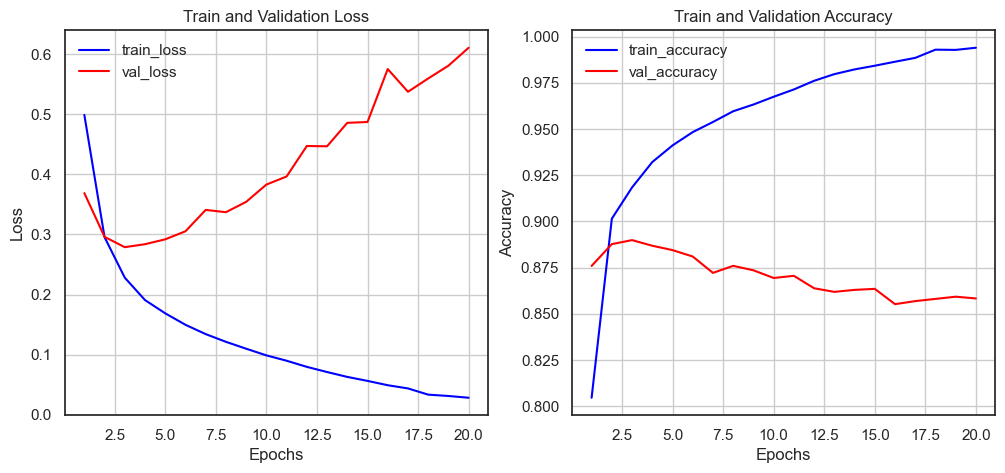

In [38]:
# history에서 loss,  val_loss,  accuracy,  val_accuracy 가져와서 차트로 시각화

import matplotlib.pyplot as plt

history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']


fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='red', label='val_loss')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, color='blue', label='train_accuracy')
ax2.plot(epochs, val_accuracy, color='red', label='val_accuracy')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

# 260309/dl/09_모델 크기 조절과 규제

## 모델 크기 조절
- 이전예제 IMDB 딥러닝 모델은 과대적합이 발생함,  이 문제를 해결하려면 모델의 크기를 조절 필요
- 모델 크기를 조절 방법 : 레이어의 유닛수 or 레이어의 수 조절 

### 데이터 로드 및 전처리

In [39]:
from keras.datasets import imdb
import numpy as np

# 모델의 학습에 사용하기 위해 원-핫 인코딩(one-hot encoding)을 위한 함수를 정의
# imdb.load_data()를 통해 IMDB 데이터를 다운로드한 뒤, 
# 10000 차원의 학습 데이터로 원-핫 인코딩을 수행

def one_hot_encoding(data, dim=10000): # 아래 imdb.load_data의 num_words를 10000으로 설정할 예정이기 때문에 dim도 10000으로 맞춰줍니다.
  results = np.zeros((len(data), dim))
  for i, d in enumerate(data):
    results[i, d] = 1.
  return results

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

x_train = one_hot_encoding(train_data)
x_test = one_hot_encoding(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

### 모델 구성 및 컴파일

In [40]:
# Dense 레이어 3개
# rmsprop 옵티마이저, binary_crossentropy 손실 함수, accuracy 지표 사용
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(10000, ), name='input'))
model.add(layers.Dense(128, activation='relu', name='hidden'))
model.add(layers.Dense(1, activation='sigmoid', name='output'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,769 (4.95 MB)

 Trainable params: 1,296,769 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

### 모델 학습

In [41]:
# 딥러닝 모델을 fit()을 이용해 학습시킵니다.
history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7904 - loss: 0.4569 - val_accuracy: 0.8805 - val_loss: 0.3096
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8926 - loss: 0.2682 - val_accuracy: 0.8741 - val_loss: 0.3060
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9158 - loss: 0.2133 - val_accuracy: 0.8871 - val_loss: 0.2797
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9282 - loss: 0.1819 - val_accuracy: 0.8840 - val_loss: 0.2829
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9463 - loss: 0.1410 - val_accuracy: 0.8813 - val_loss: 0.3173
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9511 - loss: 0.1268 - val_accuracy: 0.8802 - val_loss: 0.3166
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9670 - loss: 0.0896 - val_accuracy: 0.8742 - val_loss: 0.3468
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9776 - loss: 0.0661 - val_accuracy: 0.8667 - v

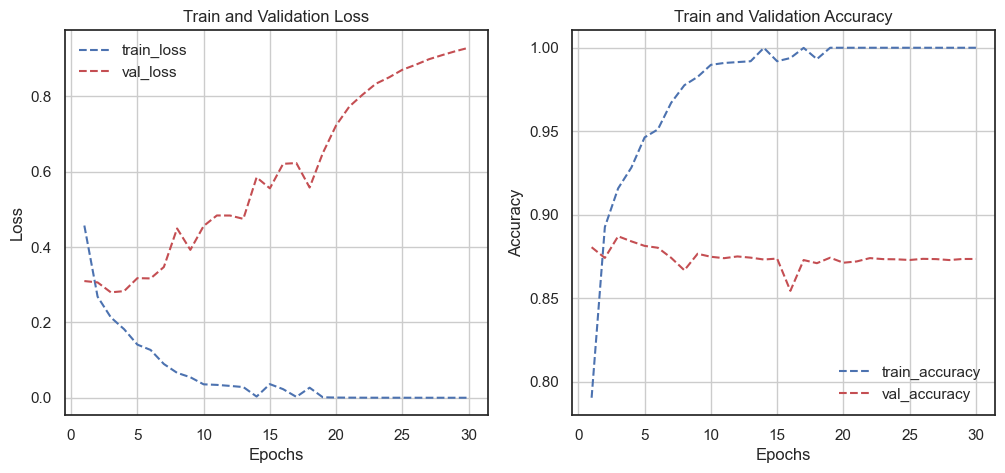

In [42]:
                    
# 모델의 지표 결과로 loss, val_loss, accuracy, val_accuracy를 차트로 살펴봅니다.
import matplotlib.pyplot as plt

history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, 'b--', label='train_loss')
ax1.plot(epochs, val_loss, 'r--', label='val_loss')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, 'b--', label='train_accuracy')
ax2.plot(epochs, val_accuracy, 'r--', label='val_accuracy')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

# 결과를 보면, 딥러닝 모델이 과대적합된 상태인 것을 알 수 있습니다. 
# 따라서 과대적합을 해결하기 위한 방법을 찾아야합니다.
plt.show() 


### 모델 크기 증가

In [43]:
#  Dense 레이어의 유닛수를 128에서 2048로 크게 증가
b_model = models.Sequential()
b_model.add(layers.Dense(2048, activation='relu', input_shape=(10000, ), name='input3'))
b_model.add(layers.Dense(2048, activation='relu', name='hidden3'))
b_model.add(layers.Dense(1, activation='sigmoid', name='output3'))

b_model.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['accuracy'])
b_model.summary()



b_model_history = b_model.fit(x_train, y_train,
                              epochs=30,
                              batch_size=512, 
                              validation_data=(x_test, y_test))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input3 (Dense)                  │ (None, 2048)           │    20,482,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output3 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,680,449 (94.15 MB)

 Trainable params: 24,680,449 (94.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - accuracy: 0.7360 - loss: 0.5521 - val_accuracy: 0.8329 - val_loss: 0.3781
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.8786 - loss: 0.2963 - val_accuracy: 0.8682 - val_loss: 0.3127
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.9133 - loss: 0.2175 - val_accuracy: 0.8286 - val_loss: 0.4145
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.9329 - loss: 0.1742 - val_accuracy: 0.8850 - val_loss: 0.2784
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step - accuracy: 0.9540 - loss: 0.1238 - val_accuracy: 0.8626 - val_loss: 0.3903
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.9683 - loss: 0.0975 - val_accuracy: 0.8792 - val_loss: 0.3528
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - accuracy: 0.9831 - loss: 0.0533 - val_accuracy: 0.8749 - val_loss: 0.4347
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.9864 - loss: 0.0525 - val_accu

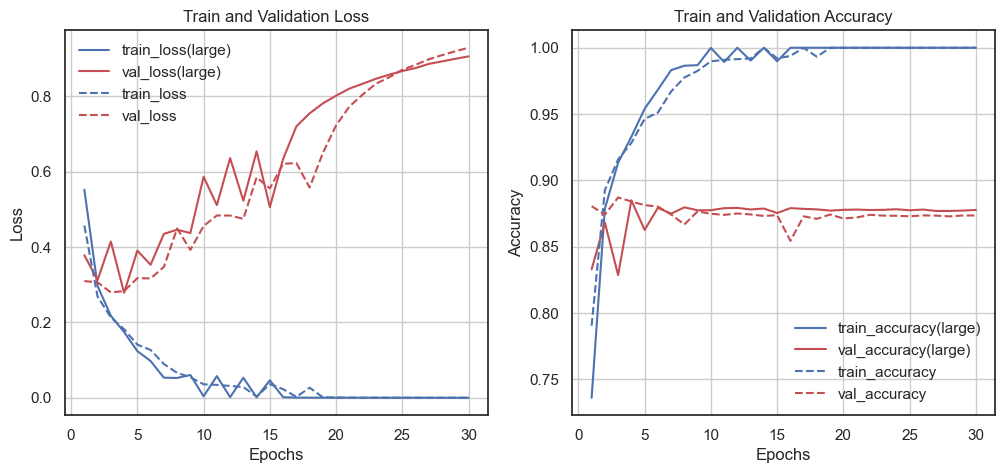

In [44]:
b_history_dict = b_model_history.history

b_loss = b_history_dict['loss']
b_val_loss = b_history_dict['val_loss']
b_accuracy = b_history_dict['accuracy']
b_val_accuracy = b_history_dict['val_accuracy']

epochs = range(1, len(b_loss) + 1)
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, b_loss, 'b-', label='train_loss(large)')
ax1.plot(epochs, b_val_loss, 'r-', label='val_loss(large)')
ax1.plot(epochs, loss, 'b--', label='train_loss')
ax1.plot(epochs, val_loss, 'r--', label='val_loss')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()


ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, b_accuracy, 'b-', label='train_accuracy(large)')
ax2.plot(epochs, b_val_accuracy, 'r-', label='val_accuracy(large)')
ax2.plot(epochs, accuracy, 'b--', label='train_accuracy')
ax2.plot(epochs, val_accuracy, 'r--', label='val_accuracy')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

### 모델 크기 감소


In [45]:
# Dense 레이어의 유닛수를 128대신 16으로 줄여서 사용
s_model = models.Sequential()
s_model.add(layers.Dense(16, activation='relu', input_shape=(10000, ), name='input2'))
s_model.add(layers.Dense(16, activation='relu', name='hidden2'))
s_model.add(layers.Dense(1, activation='sigmoid', name='output2'))

s_model.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['accuracy'])
s_model.summary()


s_model_history = s_model.fit(x_train, y_train,
                              epochs=30,
                              batch_size=512, 
                              validation_data=(x_test, y_test))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input2 (Dense)                  │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8122 - loss: 0.4877 - val_accuracy: 0.8719 - val_loss: 0.3677
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8998 - loss: 0.2924 - val_accuracy: 0.8785 - val_loss: 0.3093
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9178 - loss: 0.2288 - val_accuracy: 0.8899 - val_loss: 0.2779
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9309 - loss: 0.1935 - val_accuracy: 0.8857 - val_loss: 0.2824
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9416 - loss: 0.1670 - val_accuracy: 0.8728 - val_loss: 0.3167
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9483 - loss: 0.1506 - val_accuracy: 0.8803 - val_loss: 0.3049
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9538 - loss: 0.1359 - val_accuracy: 0.8807 - val_loss: 0.3147
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9584 - loss: 0.1240 - val_accuracy: 0.8782 - val_loss

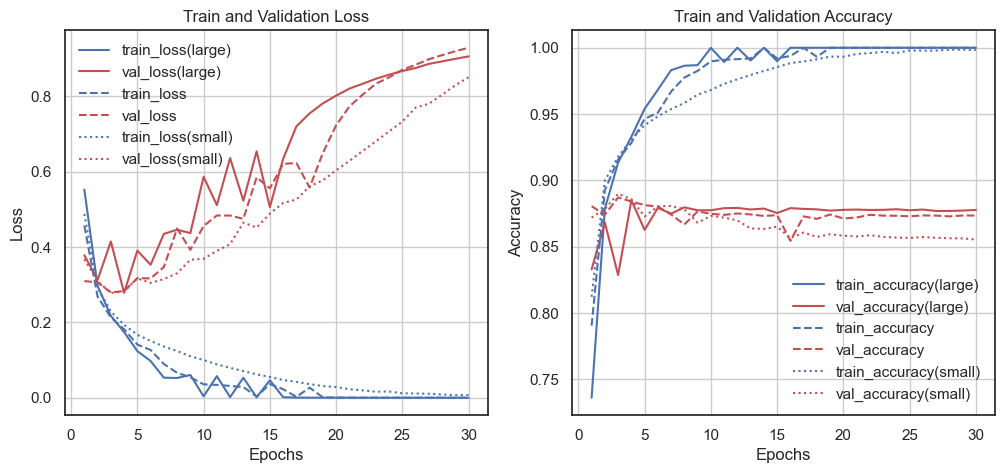

In [46]:
s_history_dict = s_model_history.history

s_loss = s_history_dict['loss']
s_val_loss = s_history_dict['val_loss']
s_accuracy = s_history_dict['accuracy']
s_val_accuracy = s_history_dict['val_accuracy']
epochs = range(1, len(s_loss) + 1)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, b_loss, 'b-', label='train_loss(large)')
ax1.plot(epochs, b_val_loss, 'r-', label='val_loss(large)')
ax1.plot(epochs, loss, 'b--', label='train_loss')
ax1.plot(epochs, val_loss, 'r--', label='val_loss')
ax1.plot(epochs, s_loss, 'b:', label='train_loss(small)')
ax1.plot(epochs, s_val_loss, 'r:', label='val_loss(small)')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, b_accuracy, 'b-', label='train_accuracy(large)')
ax2.plot(epochs, b_val_accuracy, 'r-', label='val_accuracy(large)')
ax2.plot(epochs, accuracy, 'b--', label='train_accuracy')
ax2.plot(epochs, val_accuracy, 'r--', label='val_accuracy')
ax2.plot(epochs, s_accuracy, 'b:', label='train_accuracy(small)')
ax2.plot(epochs, s_val_accuracy, 'r:', label='val_accuracy(small)')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

## 규제(Regularization)

### L1 규제

In [47]:
l1_model =  models.Sequential()

l1_model.add(layers.Dense(16, 
                          kernel_regularizer='l1',
                          activation='relu', 
                          input_shape=(10000, )))
l1_model.add(layers.Dense(16, 
                          kernel_regularizer='l1',
                          activation='relu'))
l1_model.add(layers.Dense(1, activation='sigmoid'))

l1_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

l1_model.summary()

l1_model_hist = l1_model.fit(x_train, y_train,
                             epochs=30,
                             batch_size=512,
                             validation_data=(x_test, y_test))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6318 - loss: 3.7282 - val_accuracy: 0.6968 - val_loss: 1.9143
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7364 - loss: 1.8439 - val_accuracy: 0.7613 - val_loss: 1.7769
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7417 - loss: 1.7334 - val_accuracy: 0.7453 - val_loss: 1.6972
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7633 - loss: 1.6405 - val_accuracy: 0.7687 - val_loss: 1.5900
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 1.5620 - val_accuracy: 0.7785 - val_loss: 1.5340
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7842 - loss: 1.5001 - val_accuracy: 0.7888 - val_loss: 1.4667
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7944 - loss: 1.4525 - val_accuracy: 0.7943 - val_loss: 1.4429
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7998 - loss: 1.4203 - val_accuracy: 0.8012 - val_loss

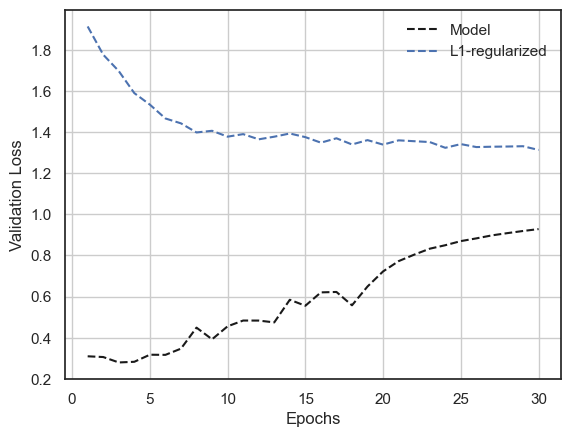

In [48]:
# 기존 모델은 Loss 값이 점점 증가하며 과대적합의 모습을 보이는 반면, 
# L1 규제 결과는 안정적으로 Loss 값이 감소

l1_val_loss = l1_model_hist.history['val_loss']

epochs = range(1, 31)
plt.plot(epochs, val_loss, 'k--', label='Model')
plt.plot(epochs, l1_val_loss, 'b--', label='L1-regularized')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

### L2 규제

In [49]:
l2_model =  models.Sequential()

l2_model.add(layers.Dense(16, 
                          kernel_regularizer='l2',
                          activation='relu', 
                          input_shape=(10000, )))
l2_model.add(layers.Dense(16, 
                          kernel_regularizer='l2',
                          activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

l2_model.summary()

l2_model_hist = l2_model.fit(x_train, y_train,
                             epochs=30,
                             batch_size=512,
                             validation_data=(x_test, y_test))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8023 - loss: 0.7408 - val_accuracy: 0.8780 - val_loss: 0.5692
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8837 - loss: 0.5232 - val_accuracy: 0.8835 - val_loss: 0.5030
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8895 - loss: 0.4743 - val_accuracy: 0.8808 - val_loss: 0.4768
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8935 - loss: 0.4456 - val_accuracy: 0.8701 - val_loss: 0.4715
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8931 - loss: 0.4286 - val_accuracy: 0.8731 - val_loss: 0.4573
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8956 - loss: 0.4148 - val_accuracy: 0.8732 - val_loss: 0.4488
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8961 - loss: 0.4037 - val_accuracy: 0.8640 - val_loss: 0.4556
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8980 - loss: 0.3970 - val_accuracy: 0.8766 - val_loss

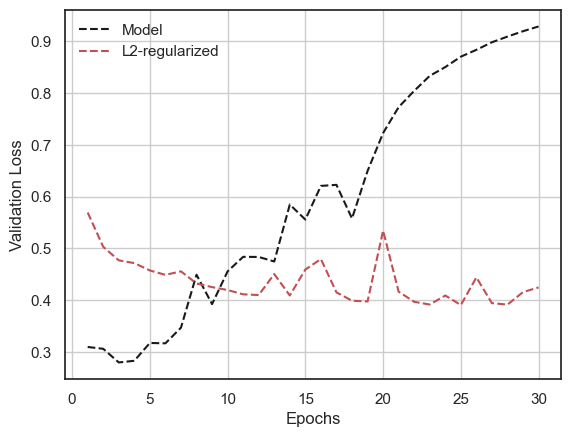

In [50]:
l2_val_loss = l2_model_hist.history['val_loss']
epochs = range(1, 31)

plt.plot(epochs, val_loss, 'k--', label='Model')
plt.plot(epochs, l2_val_loss, 'r--', label='L2-regularized')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

### L1 + L2 규제 

In [51]:
from keras import regularizers
l1_l2_model = models.Sequential()

l1_l2_model.add(layers.Dense(16,
                             kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001),
                             activation='relu', input_shape=(10000,)))
l1_l2_model.add(layers.Dense(16,
                             kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001),
                             activation='relu'))
l1_l2_model.add(layers.Dense(1, activation='sigmoid'))

l1_l2_model.compile(optimizer='rmsprop',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

l1_l2_model.summary()

l1_l2_model_hist = l1_l2_model.fit(x_train, y_train,
                                  epochs=30,
                                  batch_size=512,
                                  validation_data=(x_test, y_test))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7186 - loss: 1.0097 - val_accuracy: 0.8298 - val_loss: 0.7102
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8344 - loss: 0.6687 - val_accuracy: 0.8510 - val_loss: 0.6287
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8507 - loss: 0.6108 - val_accuracy: 0.8340 - val_loss: 0.6165
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8542 - loss: 0.5820 - val_accuracy: 0.8556 - val_loss: 0.5757
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8574 - loss: 0.5641 - val_accuracy: 0.8573 - val_loss: 0.5622
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8600 - loss: 0.5541 - val_accuracy: 0.8594 - val_loss: 0.5585
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8655 - loss: 0.5402 - val_accuracy: 0.8634 - val_loss: 0.5407
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8675 - loss: 0.5319 - val_accuracy: 0.8495 - val_

In [52]:
# 현재 네임스페이스에서 'hist'가 포함된 변수 찾기
[var for var in dir() if 'hist' in var.lower()]

['b_history_dict',
 'b_model_history',
 'history',
 'history_dict',
 'l1_l2_model_hist',
 'l1_model_hist',
 'l2_model_hist',
 's_history_dict',
 's_model_history']

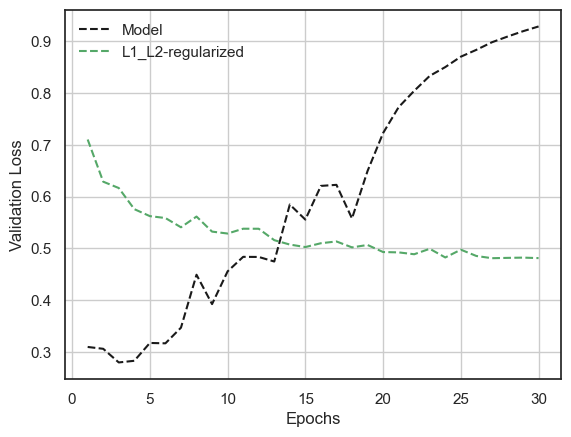

In [53]:
l1_l2_val_loss = l1_l2_model_hist.history['val_loss']

epochs = range(1, 31)
plt.plot(epochs, val_loss, 'k--', label='Model')
plt.plot(epochs, l1_l2_val_loss, 'g--', label='L1_L2-regularized')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

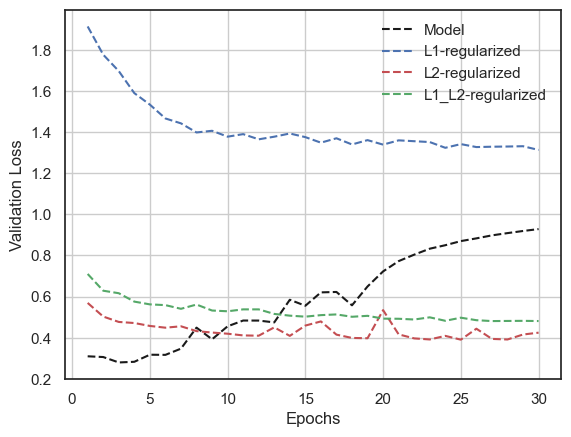

In [54]:
# L1 L2 규제를 함께 사용하는 경우는 L1 규제와 큰 차이가 없다?
epochs = range(1, 31)
plt.plot(epochs, val_loss, 'k--', label='Model')
plt.plot(epochs, l1_val_loss, 'b--', label='L1-regularized')
plt.plot(epochs, l2_val_loss, 'r--', label='L2-regularized')
plt.plot(epochs, l1_l2_val_loss, 'g--', label='L1_L2-regularized')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

## 드롭아웃(Dropout)

### 드롭아웃 (20%)

In [55]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000, )))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

# 기존 모델과 어떤 차이가 나는지 비교하기 위해 학습 히스토리를 별도로 저장
drop_20_history = model.fit(x_train, y_train,
                            epochs=30,
                            batch_size=512,
                            validation_data=(x_test, y_test))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7810 - loss: 0.4926 - val_accuracy: 0.8783 - val_loss: 0.3485
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8851 - loss: 0.3156 - val_accuracy: 0.8850 - val_loss: 0.2942
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9108 - loss: 0.2498 - val_accuracy: 0.8884 - val_loss: 0.2769
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9284 - loss: 0.2089 - val_accuracy: 0.8849 - val_loss: 0.2816
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9378 - loss: 0.1782 - val_accuracy: 0.8844 - val_loss: 0.2894
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9469 - loss: 0.1539 - val_accuracy: 0.8803 - val_loss: 0.3083
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9566 - loss: 0.1323 - val_accuracy: 0.8805 - val_loss: 0.3288
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9634 - loss: 0.1139 - val_accuracy: 0.8722 - val_los

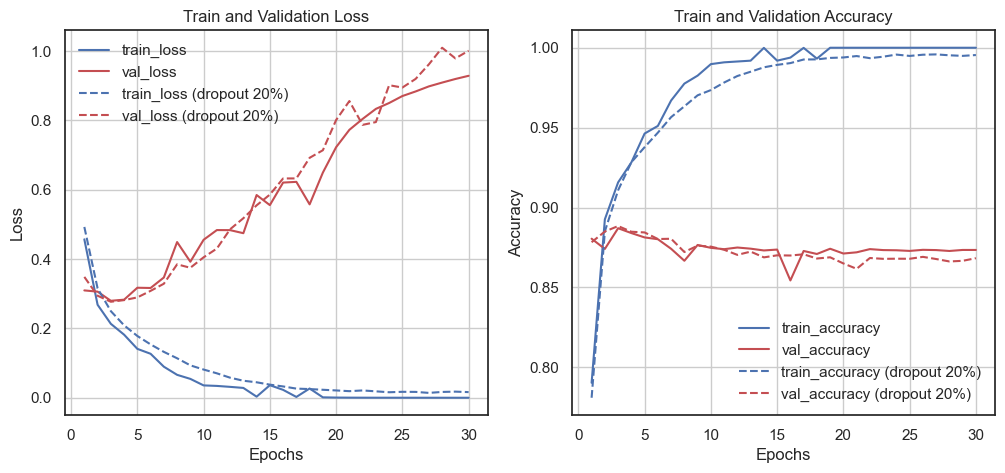

In [56]:
drop_20_dict = drop_20_history.history

drop_20_loss = drop_20_dict['loss']
drop_20_val_loss = drop_20_dict['val_loss']
epochs = range(1, len(loss) + 1)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, 'b-', label='train_loss')
ax1.plot(epochs, val_loss, 'r-', label='val_loss')
ax1.plot(epochs, drop_20_loss, 'b--', label='train_loss (dropout 20%)')
ax1.plot(epochs, drop_20_val_loss, 'r--', label='val_loss (dropout 20%)')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

drop_20_accuracy = drop_20_dict['accuracy']
drop_20_val_accuracy = drop_20_dict['val_accuracy']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, 'b-', label='train_accuracy')
ax2.plot(epochs, val_accuracy, 'r-', label='val_accuracy')
ax2.plot(epochs, drop_20_accuracy, 'b--', label='train_accuracy (dropout 20%)')
ax2.plot(epochs, drop_20_val_accuracy, 'r--', label='val_accuracy (dropout 20%)')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

### 드롭아웃 (50%)

In [57]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000, )))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

drop_50_history = model.fit(x_train, y_train,
                            epochs=30,
                            batch_size=512,
                            validation_data=(x_test, y_test))

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6743 - loss: 0.6024 - val_accuracy: 0.8498 - val_loss: 0.4563
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8048 - loss: 0.4524 - val_accuracy: 0.8794 - val_loss: 0.3348
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8573 - loss: 0.3646 - val_accuracy: 0.8878 - val_loss: 0.2899
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8857 - loss: 0.3075 - val_accuracy: 0.8855 - val_loss: 0.2829
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9040 - loss: 0.2650 - val_accuracy: 0.8862 - val_loss: 0.2784
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9199 - loss: 0.2372 - val_accuracy: 0.8882 - val_loss: 0.2849
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9284 - loss: 0.2130 - val_accuracy: 0.8775 - val_loss: 0.3267
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9342 - loss: 0.1920 - val_accuracy: 0.8850 - val_los

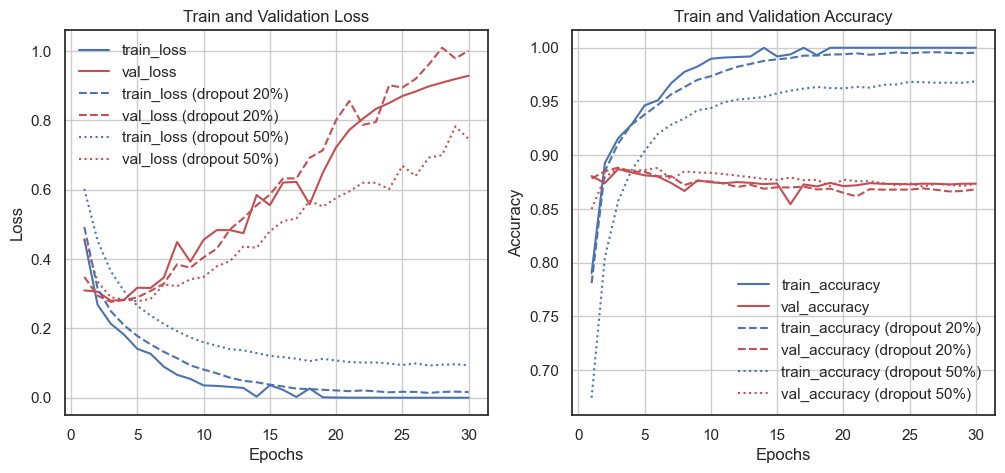

In [58]:
drop_50_dict = drop_50_history.history

drop_50_loss = drop_50_dict['loss']
drop_50_val_loss = drop_50_dict['val_loss']
epochs = range(1, len(loss) + 1)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, 'b-', label='train_loss')
ax1.plot(epochs, val_loss, 'r-', label='val_loss')
ax1.plot(epochs, drop_20_loss, 'b--', label='train_loss (dropout 20%)')
ax1.plot(epochs, drop_20_val_loss, 'r--', label='val_loss (dropout 20%)')
ax1.plot(epochs, drop_50_loss, 'b:', label='train_loss (dropout 50%)')
ax1.plot(epochs, drop_50_val_loss, 'r:', label='val_loss (dropout 50%)')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

drop_50_accuracy = drop_50_dict['accuracy']
drop_50_val_accuracy = drop_50_dict['val_accuracy']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, 'b-', label='train_accuracy')
ax2.plot(epochs, val_accuracy, 'r-', label='val_accuracy')
ax2.plot(epochs, drop_20_accuracy, 'b--', label='train_accuracy (dropout 20%)')
ax2.plot(epochs, drop_20_val_accuracy, 'r--', label='val_accuracy (dropout 20%)')
ax2.plot(epochs, drop_50_accuracy, 'b:', label='train_accuracy (dropout 50%)')
ax2.plot(epochs, drop_50_val_accuracy, 'r:', label='val_accuracy (dropout 50%)')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()